In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import seaborn as sns
import shap

from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED,PREFERENCE_PROCESSED,BOOKING_MODEL,BEST_PARAMS,DEV_OOF_METRICS,PROD_OOF_METRICS,OOF_ADD,REPORTS_FIGURE
from cdc_ml.plots import booking_rate_plot,bootstrap_distribution,plot_calibration_by_volume,bootstrapped_gain_curve,plot_additive_heatmap,concentration_share,production_visualization,boostrap_summary
from cdc_ml.modeling.data import make_holdout_split
from cdc_ml.features.build_features import build_features,get_whale_users,get_pc_user
from cdc_ml.datasets.preference.schema import CleanedPreference
from cdc_ml.modeling.evaluation import cramers_v,compare_feature_sets,paired_t,baseline_pr_auc,pr_auc_ci_by_user,adversarial_validation,per_customer_at_budget,gains_bootstrap
from cdc_ml.modeling.config import CHOSEN_FEATURES



2026-06-10 00:06:09.735 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


## Orientation

This notebook documents the modeling decisions behind the booking model. Given a poll's timing and a customer's stated preferences, the model estimates the probability that the poll produces a slot within those preferences. The README describes the end-to-end system; this notebook focuses on model development and evaluation.

The sections are organized in the same sequence as the analysis:

- **Domain & validity** — data sources, assumptions, and the limits of what can be inferred from the available data
- **Evaluation design** — data splitting strategy, validation assumptions, and evaluation metrics
- **Features** — candidate features and the process used to arrive at the final feature set
- **Baseline** — reference models that establish the minimum performance threshold
- **Feature ablation** — attribution of predictive lift and feature-selection methodology
- **Hyperparameter tuning** — search procedure and its interaction with model evaluation
- **Final evaluation** — held-out performance and interpretation of the OOF–test gap
- **Calibration** — conversion of model scores into calibrated probability estimates
- **Operational impact** — gains-curve analysis and the per-customer safeguard used in deployment
- **Interpretation** — model behavior and feature influence analysis using SHAP
- **Limitations & business impact** — key caveats and the operational decisions informed by the model

## Domain & validity

Customer data comes from two sources. The polling cycle records how long a customer has been polling and which cycles they were active in. The preference window records every day–timeslot combination requested within a cycle.

Slots become available only when another learner cancels. The polling bot re-polls customers at randomized intervals throughout the day, but individual poll timestamps are not retained. The finest available temporal resolution is therefore one hour. Polling records are aggregated to one row per `(customer, polling_hour)`, which is also the finest resolution available to the model. The model cannot distinguish between polls occurring at 09:05 and 09:55, which is why temporal features are limited to `polling_hour` and `polling_dow`.

### Known sources of bias

Two characteristics of the dataset affect the interpretation of all downstream results.

**The sample is conditioned on success.** Nearly all collected cycles contain at least one booking. Restricting the dataset to cycles with `≥1 booking` introduces selection bias because retained cycles and preference windows are systematically easier to convert into bookings than the full population.

The effect differs across customer groups. One-team customers can book from any team and generally book more easily, while common-pool customers compete within a shared pool and book less frequently. The success filter therefore removes relatively few one-team customers but excludes many common-pool customers, leaving a disproportionately successful subset of the common-pool population. As a result, the observed performance gap between the two groups is likely compressed relative to the true population-level difference.

Consequently, the reported metrics describe model behaviour on the collected sample rather than the full booking population and should not be interpreted as calibrated estimates of real-world booking rates.

**Polling is preference-conditioned.** The bot only polls within a customer's stated preferences. While polling coverage is distributed across the clock, observed slots are determined by self-selected preferences rather than by a uniform sample of all possible slots.

This has two implications. First, the dataset only contains observations from preferred day–timeslot regions, so predictions outside those regions represent extrapolation. In practice this is consistent with deployment because the live system only evaluates preference-conditioned polls. Second, the preference-conditioning effect compounds the success filter. Because preferences are self-selected and the dataset is already conditioned on successful cycles, the retained preference configurations are biased toward those that historically produced bookings. Customers whose preferences never resulted in a booking are largely absent from the sample. Preference-derived features are therefore learned from an optimistic preference distribution.

Within retained cycles, the dataset is otherwise complete. Both successful and unsuccessful polls are recorded, and polling operates continuously throughout the day, so there are no structural zero periods in which bookings are impossible.

All cleaned and derived datasets are validated with Pandera before use. Validation checks include datetime formatting, date-range sanity checks (for example, catching a year entered as 2055 instead of 2025), enforcement that polling timestamps precede the final preference date of the cycle, non-null constraints on required fields, binary columns restricted to `{0, 1}`, and range checks for impossible values such as negative preference-day counts.

The data is drawn from real customer activity, with customer identifiers anonymized to nicknames. Sample sizes are modest—particularly in the test set—so out-of-fold (OOF) results are reported alongside test results where useful.

In [3]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)

### Pandera validation example

The schema below enforces timestamp integrity and that `pref_start` always precedes `pref_end`.

In [4]:
# this schema ensures timestamp integrity and also pref_start is always earlier than pref_end
CleanedPreference.validate(df_pref)

,id,username,day_of_week,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-19 23:00:00+08:00,0,0,0,0,0,1,1
1,0,ajithak,2,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-20 23:00:00+08:00,0,0,0,0,0,1,1
2,0,ajithak,3,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-21 23:00:00+08:00,0,0,0,0,0,1,1
3,0,ajithak,4,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-22 23:00:00+08:00,0,0,0,0,0,1,1
4,0,ajithak,5,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-23 23:00:00+08:00,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529,121,addity,2,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-10 23:00:00+08:00,0,0,0,0,0,1,1
2530,121,addity,3,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-11 23:00:00+08:00,0,0,0,0,0,1,1
2531,121,addity,4,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-12 23:00:00+08:00,0,0,0,0,0,1,1
2532,121,addity,5,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-13 23:00:00+08:00,1,1,1,1,1,1,1


### The three source tables

`df` is the hourly polling log (one row per customer-hour), `df_class` is the customer-type table (one-team vs common-pool), and `df_pref` is the preference windows. 37 customers in total.

In [5]:
print(f"Total unique customers {df["username"].nunique()}")

Total unique customers 37


In [6]:
print("polling records")
df.head()

polling records


,id,username,cycle_start,cycle_end,polling_at,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,has_booking
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:00:00+08:00,8,19,1,9,8,19,1,9,0.0,False
1,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 10:00:00+08:00,8,19,1,9,8,19,1,10,1.0,False
2,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 11:00:00+08:00,8,19,1,9,8,19,1,11,2.0,False
3,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 12:00:00+08:00,8,19,1,9,8,19,1,12,3.0,False
4,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 13:00:00+08:00,8,19,1,9,8,19,1,13,4.0,False


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29612 entries, 0 to 29611
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 29612 non-null  int64                         
 1   username           29612 non-null  str                           
 2   cycle_start        29612 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end          29612 non-null  datetime64[us, Asia/Singapore]
 4   polling_at         29612 non-null  datetime64[us, Asia/Singapore]
 5   cycle_start_month  29612 non-null  int32                         
 6   cycle_start_day    29612 non-null  int32                         
 7   cycle_start_dow    29612 non-null  int32                         
 8   cycle_start_hour   29612 non-null  int32                         
 9   polling_month      29612 non-null  int32                         
 10  polling_day        29612 non-null  int32     

In [8]:
print("customer class")
df_class.tail()

customer class


,username,class_type,is_one_team
66,fir,3a,0
67,afellow,3a,0
68,isyaf,3a,0
69,jun,3a,0
70,max,3a,1


In [9]:
print("preference windows")
df_pref.head()

preference windows


,id,username,day_of_week,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-19 23:00:00+08:00,0,0,0,0,0,1,1
1,0,ajithak,2,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-20 23:00:00+08:00,0,0,0,0,0,1,1
2,0,ajithak,3,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-21 23:00:00+08:00,0,0,0,0,0,1,1
3,0,ajithak,4,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-22 23:00:00+08:00,0,0,0,0,0,1,1
4,0,ajithak,5,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-23 23:00:00+08:00,0,0,0,0,0,1,1


## Evaluation design

### Assumptions

The data spans August 2025 to April 2026, approximately nine months. Over this period, booking demand is assumed to be approximately cyclical and stationary: recurring intra-week patterns are expected to repeat across weeks rather than drift along an absolute calendar timeline.

A temporal train/test split is typically used to evaluate performance under distributional drift between past and future observations. Under the stationarity assumption, such drift is not expected within the observed window, so the analysis does not use a temporal split. Instead, the model learns recurring weekly patterns (for example, the behaviour associated with a Tuesday 09:00 poll) rather than absolute position in time. Given cyclical time features and customer preference features, polls are treated as exchangeable observations and no temporal ordering is modelled.

This assumption cannot be fully validated from nine months of data. The observation window is sufficient to observe repeated weekly cycles but not long enough to establish longer-horizon seasonal effects. Potential annual seasonality therefore remains outside the scope of the available data and is treated as a limitation.

### Split strategy

The primary objective is generalisation to unseen customers (cold start). Polls from the same customer share highly similar preference and timing characteristics, so a random row-level split would introduce leakage by allowing the model to be evaluated on customers whose patterns were already observed during training.

To prevent this, both the train/test split and all cross-validation folds are grouped by username, ensuring that each customer appears entirely within either the training or evaluation partition. The username field is used only as a grouping key and is never provided as a model feature.

The positive class is highly imbalanced (~1.3%), so StratifiedGroupKFold is used to preserve customer-level separation while maintaining approximately consistent positive rates across folds. Out-of-fold (OOF) predictions are pooled across folds for calibration and gains-curve analysis, while fold-level scalar metrics are retained primarily to provide context on variability.

Dataset size and usage concentration limit the amount of variability that can be estimated from fold assignment alone. A small number of high-volume customers account for a substantial share of observations, leaving few materially distinct ways to construct balanced folds. As a result, repeated random seeds produce only minor changes in fold composition and provide limited information about uncertainty.

Uncertainty is therefore estimated using customer-level bootstrap confidence intervals, which resample customers rather than individual rows. This propagates the dominant source of evaluation variance—the customer population itself—while preserving the grouping structure used throughout the analysis.

Throughout the feature-ablation stage, fold-to-fold standard deviations are reported for context only. Feature-selection decisions are based primarily on cross-validated point estimates and segment-level lift, with bootstrap confidence intervals used as the final validation step.

### Metrics

Bookings are rare (~1.3% prevalence), which determines the metric hierarchy.

**PR-AUC (primary).** Under severe class imbalance, ROC-AUC can remain high even when performance on the minority class is weak because the metric is heavily influenced by the large number of true negatives. PR-AUC focuses directly on the booking class and therefore provides the most informative summary of ranking performance.

**Brier score (secondary, calibration).** At this prevalence, the Brier score is dominated by correctly predicted negatives, making its absolute value difficult to interpret. It is used primarily as a relative measure of probability quality, particularly when comparing predictions before and after calibration.

**Recall-vs-polls gains curve (operational).** The operational objective is to reduce polling volume while preserving bookings. The gains curve measures the trade-off directly by showing the fraction of bookings retained at different polling budgets. This metric is therefore the most relevant representation of deployment impact.

The operational evaluation indicates that approximately 40–50% of polling could be removed while retaining roughly 90% of bookings on the held-out sample. This result should be interpreted as an offline counterfactual and carries substantial uncertainty because of the small evaluation panel.

### Heavy-tailed (whale) users

Usage is highly concentrated: approximately eight whale customers account for roughly half of all polling activity, while five account for roughly half of all bookings. Aggregate metrics are therefore heavily influenced by a small number of customers and can obscure behaviour on the broader population.

To address this, all evaluations are reported separately for whale and non-whale segments in addition to pooled results. The two segments exhibit materially different behaviour, and estimates within the whale segment are effectively driven by a very small number of customers. Consequently, feature-selection decisions are evaluated at both the pooled and segment level.

For this reason, ablation results include `whale_pr_lift` and `non_whale_pr_lift` alongside pooled PR-AUC. A feature is only considered beneficial if its improvement is consistent within the segment of interest rather than being driven solely by changes in the pooled metric.


In [10]:
df = build_features(df,df_pref,df_class)

### Train/test split

StratifiedGroupKFold grouped by customer, with one fold (~20% of customers) held out as the test set. The same splitter and grouping are reused for cross-validation, so the holdout and the CV both measure cold-start, unseen-customer performance.

In [11]:
df_train , df_test = make_holdout_split(df)

Train share -> 0.7927191679049034
Test share -> 0.2072808320950966
Baseline positive rate -> 0.013170336350128327
Train positive rate -> 0.013759904575274772
Test positive rate -> 0.010915607689801238


In [12]:
print(f"train unique users: {df_train["username"].nunique()}")
print( f"test unique users: {df_test["username"].nunique()}")

train unique users: 30
test unique users: 7


In [13]:
has_booking_counts = df["has_booking"].value_counts()
has_booking_share = df["has_booking"].value_counts(normalize=True)

has_booking_stats = pd.concat([has_booking_counts, has_booking_share], axis=1)
has_booking_stats.columns = ["count", "share"]

has_booking_stats

,count,share
has_booking,,
False,29222,0.98683
True,390,0.01317


### Polling volume is concentrated

Distribution of polling volume across customers. The long right tail is the whale concentration the segmented metrics account for.

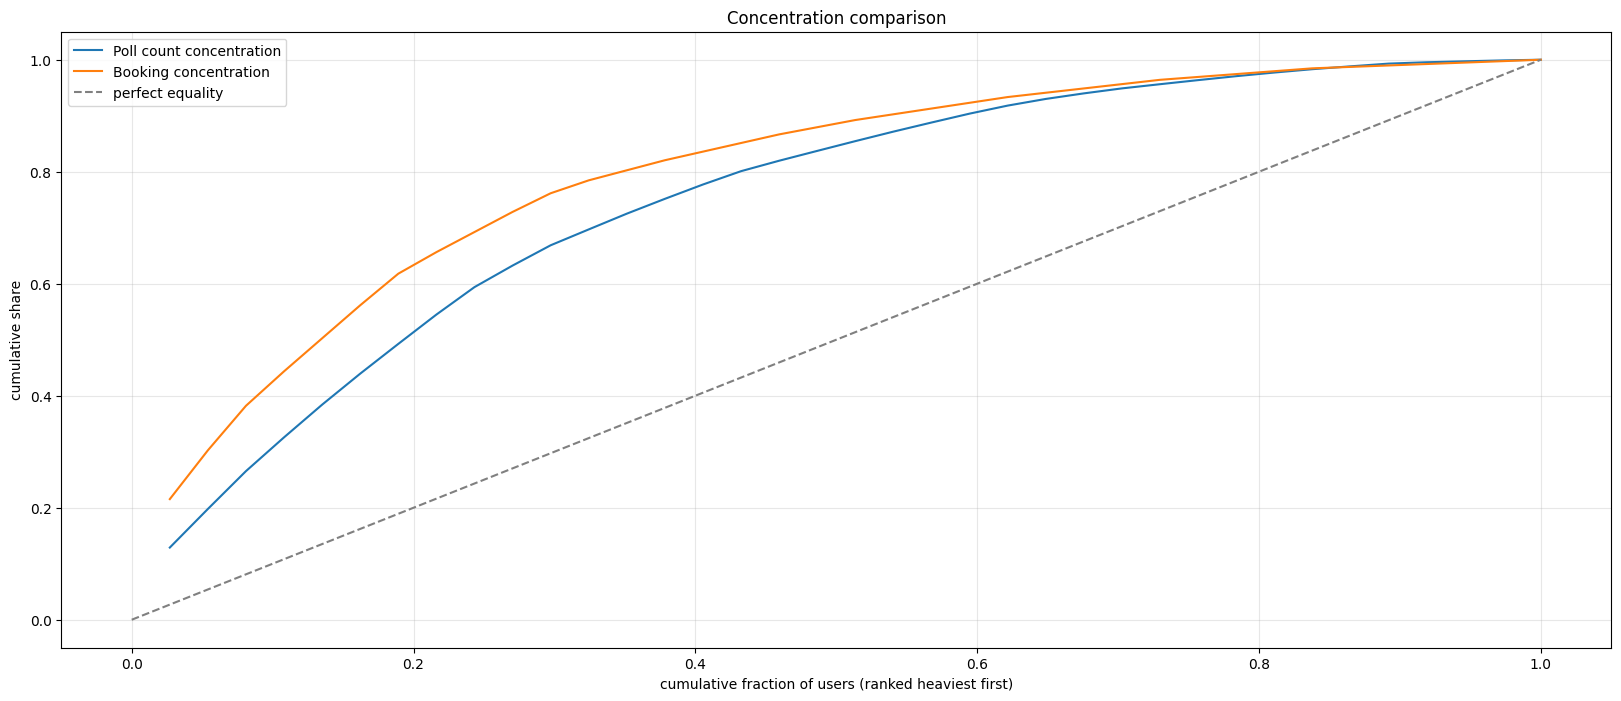

In [14]:
fig = concentration_share(df)

## Features

Feature development follows a funnel structure. Candidate features are drawn from four families and then filtered according to three criteria: availability at inference time, redundancy with existing features, and demonstrated predictive value.

### Initial candidate pool

| Family        | Candidates                                                                                        |
| ------------- | ------------------------------------------------------------------------------------------------- |
| Cycle         | `cycle_start_month`, `cycle_start_day`, `cycle_start_dow`, `cycle_start_hour`, `hours_into_cycle` |
| Polling       | `polling_month`, `polling_day`, `polling_dow`, `polling_hour`                                     |
| Preference    | `pref_coverage`, `pref_valid`, `pref_unique_day`, `pref_unique_timeslot`, `pref_dow_count_0…6`    |
| Customer-type | `class_type`, `is_one_team`                                                                       |

### Retained features

**Polling features.** `polling_hour` carries the strongest temporal signal. Since slots only become available when another learner cancels, the time at which a slot appears is expected to be a primary predictor of booking probability. The interpretation section shows that `polling_hour` also receives substantial SHAP attribution, consistent with this expectation.

`polling_dow` is retained as a main effect because booking rates differ systematically across the week, with lower rates observed on weekends. A potential interaction between `polling_hour` and `polling_dow` is evaluated separately in the baseline analysis through comparison of additive and joint lookup-table formulations.

**Preference features.** These features describe the structure of the customer's preference window.

* `pref_coverage` — number of unique `(day, timeslot)` combinations requested (for example, {Tue 09:00, Wed 09:00, Thu 09:00} = 3, out of a possible 49).
* `pref_valid` — number of valid preference days remaining at the time of polling. For example, polling on 2026-01-25 against a preference range of 2026-02-02 → 2026-02-05 yields four valid days, whereas a range of 2026-01-23 → 2026-01-26 yields two. For sparse, non-contiguous preferences, the value is simply the count of future preference dates.
* `pref_unique_day` / `pref_unique_timeslot` — number of distinct requested days and timeslots.
* `pref_dow_count_0…6` — weekday-specific counts of requested timeslots. For example, three Tuesday timeslots correspond to `pref_dow_count_1 = 3`.

These features are deterministic functions of the cycle configuration and require no fitting procedure. As a result, they introduce no fold-specific estimation step and no associated leakage pathway. They are also available at inference time because preferences are declared at cycle creation and the poll timestamp is known when scoring occurs.

Collectively, these variables describe the breadth, remaining availability, and temporal distribution of a customer's preferences.

**Customer-type features.** `class_type` and `is_one_team` encode the distinction between one-team and common-pool customers, which represents a major source of variation in booking difficulty.

### Removed features

**Cycle features.** All cycle features are excluded for three reasons. First, some are unavailable at inference time. For example, `cycle_end` is only available retrospectively and cannot be known when a live poll is scored. Second, several cycle-start variables are strongly associated with the corresponding polling features (`cycle_start_day`, `cycle_start_month`, and `cycle_start_hour`), as measured by Cramér's V, making them largely redundant. Third, cycle-start timestamps are affected by a backlog artifact: when the true cycle-start time is unavailable, the timestamp is defaulted to 00:00. This contaminates both `cycle_start_hour` and the derived `hours_into_cycle` feature.

**`polling_day`.** This feature is strongly associated with `polling_dow` and therefore contributes little additional information. Its wide confidence interval further suggests that day-of-month effects are weak relative to the dominant weekly pattern.

**`polling_month`.** With only nine months of observations, month effects are difficult to separate from customer activity patterns. The dataset also does not cover all twelve months, meaning any learned month effect would require extrapolation to unseen calendar months.

### Final candidate set

`polling_dow`, `polling_hour`, `pref_coverage`, `pref_valid`, `pref_unique_timeslot`, `pref_unique_day`, `pref_dow_count_0…6`, `class_type`, `is_one_team`


### Time features

Boxplots and swarm plots of polling volume by candidate time feature. The `polling_*` features (hour, dow) are far more evenly spread than the `cycle_*` features, which carry large variance.

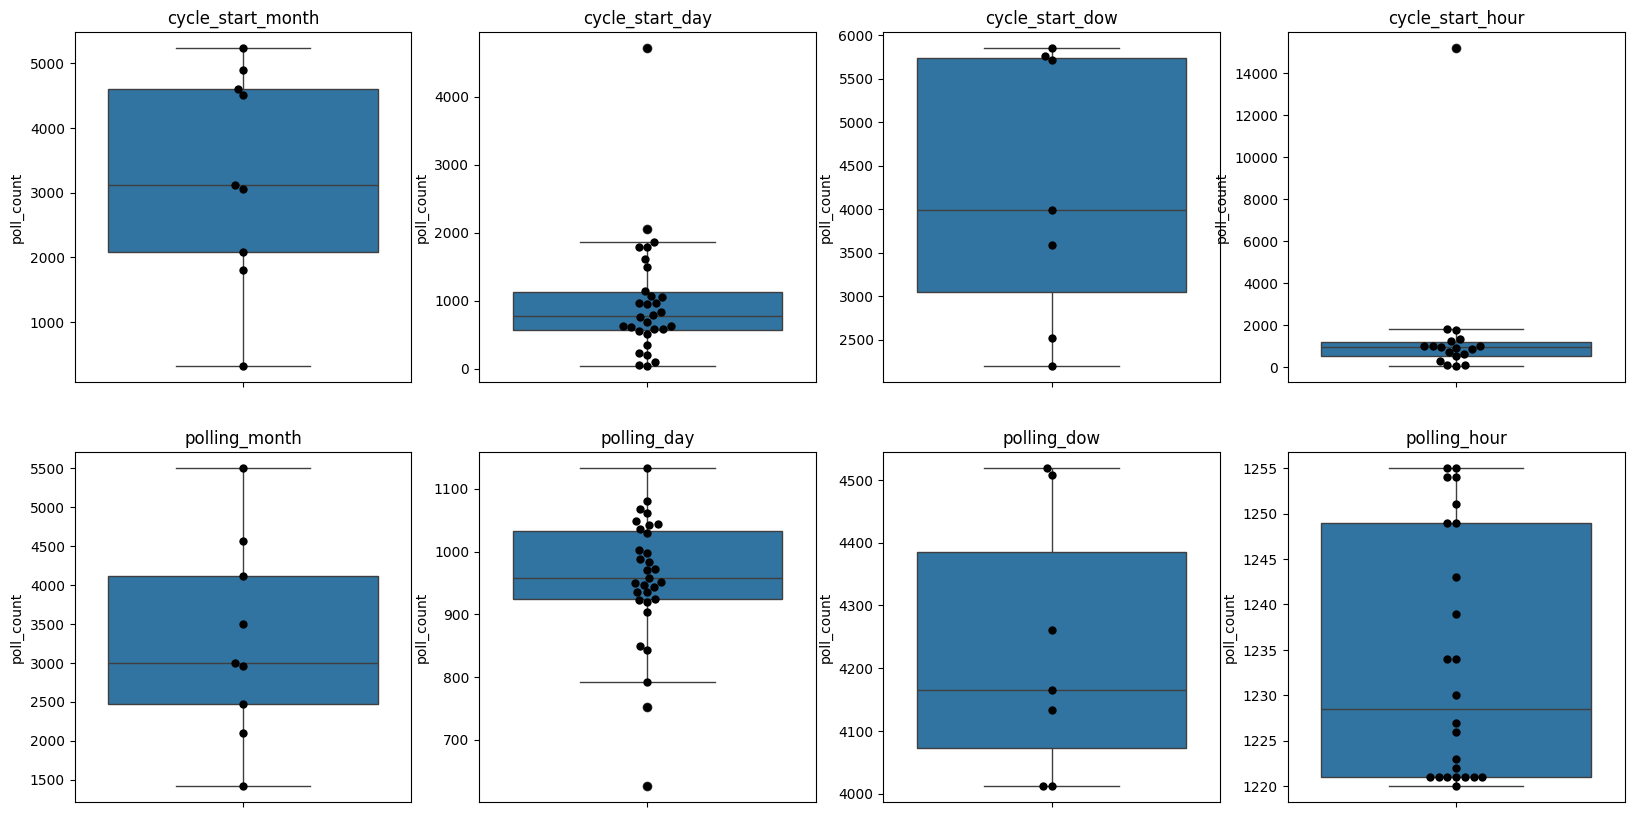

In [15]:
fig,axes = plt.subplots(2,4,figsize=(20,10))

plot_lists = [["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour",],
              ["polling_month","polling_day","polling_dow","polling_hour"]
              ]

for i in range(2):
    for j in range(4):
        current = plot_lists[i][j]
        count = df.groupby(current)["username"].count().reset_index(name="poll_count")
        sns.boxplot(y=count["poll_count"],ax=axes[i][j])
        sns.swarmplot(y=count["poll_count"], color="black", size=6,ax=axes[i][j])
        axes[i][j].set_title(current)  

Cramér's V confirms the `cycle_*` features are largely redundant with their `polling_*` counterparts.

In [16]:
v,p=cramers_v(df,"cycle_start_month","polling_month")
print(v,p)
v,p=cramers_v(df,"cycle_start_day","polling_day")
print(v,p)


χ²=145350.9  p=0.00e+00  V=0.783  (df=8)  → large
0.7833034250128832 0.0
χ²=31936.4  p=0.00e+00  V=0.193  (df=29)  → large
0.19284562880375147 0.0


`polling_hour` and `polling_dow` carry the clearest booking-rate signal.

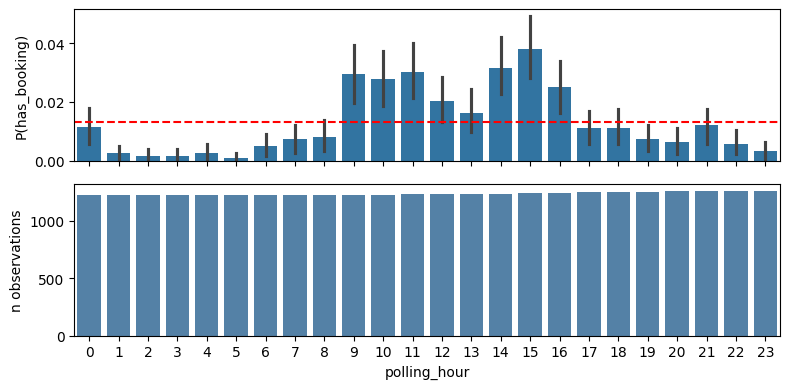

In [17]:
booking_rate_plot(df,"polling_hour")

`polling_dow` shows a real weekend penalty, so it's kept as a main effect. That raises the obvious question — does it interact with `polling_hour` (is Tuesday 6pm different from Saturday 6pm)? If there's an interaction, a joint dow×hour table should beat an additive one. The baseline section tests exactly that.

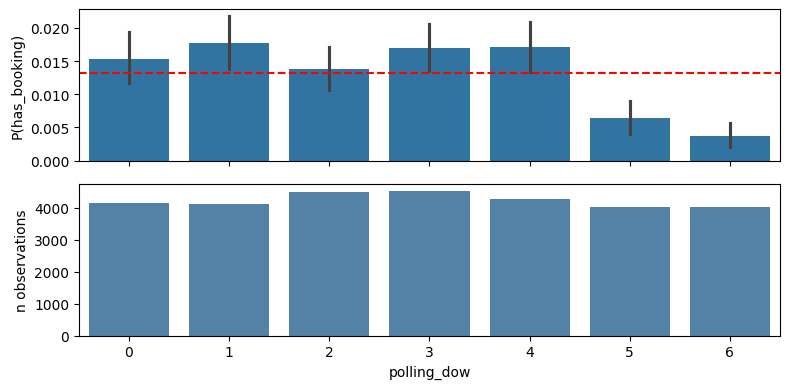

In [18]:
booking_rate_plot(df,"polling_dow")

`polling_day` is dropped: Cramér's V shows it's largely redundant with `polling_dow`, and its wide confidence band says the day-of-month axis is mostly noise.

In [19]:
cramers_v(df,"polling_day","polling_dow")

χ²=11637.7  p=0.00e+00  V=0.256  (df=6)  → large


(np.float64(0.2559318470836812), np.float64(0.0))

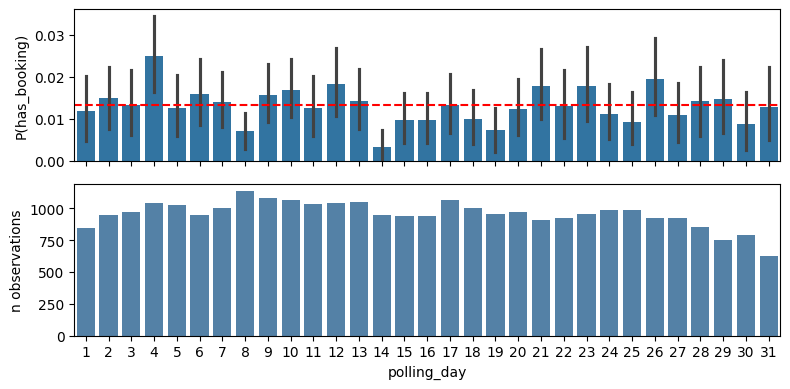

In [20]:
booking_rate_plot(df,"polling_day")

`polling_month` is dropped too. With only nine months of data it mostly reflects which customers were active in a given month rather than any stable seasonal effect, and since the data doesn't span all twelve months the model would have to extrapolate to months it never saw.


## Baseline

The baseline models establish the predictive value of timing information before introducing preference or customer-level features. This provides a reference point against which subsequent improvements can be attributed. All baseline models use only `polling_dow` and `polling_hour`.

The baseline design also evaluates the structure of the timing signal: whether weekday and hour effects are approximately additive or whether a meaningful `dow × hour` interaction exists.

Two lookup-table (LUT) formulations are constructed for this purpose. The additive LUT models weekday and hour effects independently and combines them additively. The joint LUT models the complete `dow × hour` interaction through a separate estimate for each cell.

All lookup tables are smoothed toward a prior to reduce variance in sparsely populated cells. Marginal and additive estimates are shrunk toward the global base-rate logit, while joint-cell estimates are shrunk toward their corresponding additive predictions. This is particularly important at a positive rate of approximately 1.3%, where many cells contain limited observations and unsmoothed estimates are highly sensitive to sampling variation.

Two tree-based models are included as complementary baselines. A Random Forest can represent nonlinear relationships and feature interactions without requiring them to be specified explicitly. XGBoost serves as a high-capacity tabular learner and is also capable of modelling interaction effects. Agreement between these models and the additive LUT provides an independent assessment of whether additional model flexibility extracts meaningful information from the time features alone.

| Baseline                 | Assumes                      | Role                     |
| ------------------------ | ---------------------------- | ------------------------ |
| Constant base rate       | Base rate everywhere         | Absolute floor           |
| `marg_dow` / `marg_hour` | One axis, smoothed           | Single-feature baselines |
| Additive LUT             | `dow + hour`, no interaction | Reference timing model   |
| Joint LUT                | Full `dow × hour` cells      | Interaction test         |
| Random Forest / XGBoost  | Flexible time-only models    | Cross-family comparison  |

Across all time-only models, performance converges to the additive LUT. Neither the Random Forest nor XGBoost produces a meaningful improvement despite their ability to represent interaction effects. Time features alone increase PR-AUC to approximately 2.1× the base rate, representing the predictive value available from timing information in isolation.

The additive LUT is therefore used as the timing baseline. Any further performance improvement must come from additional information contained in preference or customer-level features rather than from increased model complexity applied to the same timing variables.


In [21]:
baseline_pr_auc()

,pr_auc,pr_auc_lift,pr_auc_std,whale_lift,non_whale_lift
model,,,,,
add,0.029619,2.152563,0.013156,2.646444,1.993079
const,0.011377,0.826840,0.005123,0.959717,0.985921
joint,0.026846,1.951047,0.011018,2.331795,1.838067
marg_dow,0.014241,1.034947,0.006884,1.074694,1.202607
marg_hour,0.025729,1.869848,0.010831,2.455259,1.618822
rf,0.027604,2.006123,NaN,2.421704,1.935223
xgb,0.029475,2.142060,0.013288,2.656756,1.960292


### No dow × hour interaction

The additive and joint lookup tables are statistically indistinguishable on PR-AUC. The additive LUT exceeds the joint LUT by +0.0028, compared with a fold-to-fold standard deviation of 0.013. The observed difference is therefore substantially smaller than the natural variability introduced by fold assignment and provides no evidence that the two models perform differently.

Among the baseline models, the joint LUT is uniquely capable of representing a full `dow × hour` interaction. If meaningful interaction effects were present, performance would be expected to improve relative to the additive formulation. No such improvement is observed.

The results therefore suggest that weekday and hour effects are adequately described by an additive structure. The additive LUT is retained as the timing baseline, and subsequent modelling does not treat `polling_dow` and `polling_hour` interactions as a primary source of predictive signal.

The interpretation section reaches the same conclusion through SHAP analysis, where no substantial interaction structure is observed between the two timing features.


Heatmap of the additive LUT — booking-rate logit deviation by weekday and hour.

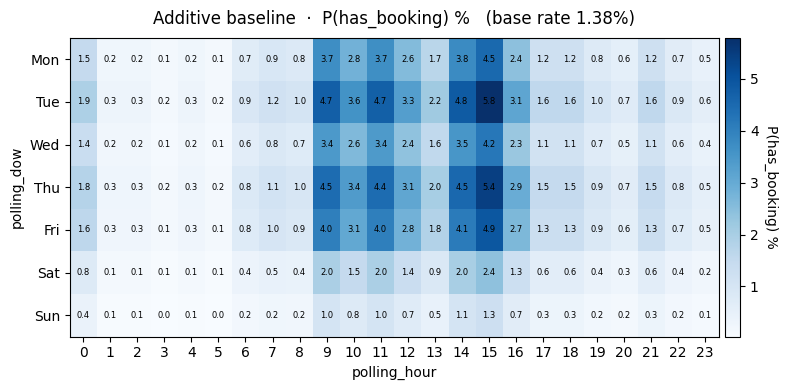

In [22]:
fig,_,_=plot_additive_heatmap(df_train[CHOSEN_FEATURES],df_train["has_booking"])

## Feature ablation & selection

### Feature selection on a small, imbalanced dataset

The dataset is small and highly imbalanced: bookings represent approximately 1.3% of observations and are distributed across only a few dozen customer groups. Under these conditions, small cross-validation differences are difficult to interpret.

Individual PR-AUC deltas are therefore not treated as evidence on their own. With relatively few positive examples, changes in fold composition can be driven by the placement of a small number of influential customers. Consequently, feature-selection decisions are based primarily on three considerations:

* **Redundancy.** Features that describe substantially overlapping information are not retained simultaneously without evidence of additional predictive value.
* **Parsimony.** Additional variables are retained only when they provide measurable benefit.
* **Effect size.** Features whose removal causes a substantial reduction in performance receive greater weight than small changes that are difficult to distinguish from evaluation variability.

The PR-AUC deltas reported below should therefore be interpreted as effect-size estimates rather than significance tests.

### Leave-one-out and group ablations

Two complementary ablation strategies are used.

**Leave-one-out (LOO) ablation** removes a single feature and measures the resulting change in pooled PR-AUC. This evaluates the marginal contribution of a feature given that all remaining features are still available.

However, correlated features can mask one another's contribution. When multiple variables encode similar information, removing a single feature may have little effect because the remaining features continue to provide similar signal.

To address this, **group ablation** removes entire correlated feature blocks simultaneously. This makes it possible to evaluate the collective contribution of a feature family rather than the contribution of any individual member.

Whale and non-whale lift are tracked throughout the analysis as a secondary diagnostic to ensure that pooled improvements do not conceal substantial degradation within either segment.

The initial feature set consists of:

`polling_hour`, `polling_dow`, `pref_coverage`, `pref_unique_timeslot`, `pref_unique_day`, `pref_valid`, `pref_dow` (seven weekday-count columns), `class_type`, and `is_one_team`.

### Stage 1 — remove `pref_dow`

`pref_dow` consists of seven sparse weekday-count features.

Removing the entire block produces essentially no change in pooled PR-AUC. Performance increases slightly, but the magnitude of the change is small relative to the variability already observed across folds.

Because the block does not demonstrate a measurable contribution, all seven columns are removed. This reduces the feature set from nine variables to eight.

### Stage 2 — simplify the preference block

The remaining preference features—`pref_coverage`, `pref_unique_day`, `pref_unique_timeslot`, and `pref_valid`—represent different summaries of the same underlying preference configuration and exhibit substantial correlation.

The LOO results suggest that `pref_coverage` and `pref_unique_day` contribute little additional information. Removing `pref_coverage` slightly improves PR-AUC, while removing `pref_unique_day` produces almost no change.

The effect of `pref_valid` is less clear. Its removal decreases PR-AUC by approximately 7%, but the magnitude of the change remains modest relative to the uncertainty associated with the dataset.

In contrast, `pref_unique_timeslot` produces one of the largest observed effects. Removing it reduces pooled PR-AUC by approximately 18%.

The group-ablation results reinforce this conclusion. Removing `pref_coverage`, `pref_unique_day`, and `pref_valid` simultaneously does not reduce performance; pooled PR-AUC increases slightly.

Taken together, these results indicate that most of the predictive value within the preference block is concentrated in `pref_unique_timeslot`. The remaining preference summaries appear largely redundant once the rest of the feature set is available.

After this stage, `pref_unique_timeslot` is retained as the sole preference-derived feature.

### Stage 3 — validate the remaining features

After removing redundant preference variables, the remaining features exhibit substantially larger ablation effects.

Removing `class_type` reduces pooled PR-AUC by approximately 38%.

Removing `is_one_team` reduces pooled PR-AUC by approximately 43%.

Removing `pref_unique_timeslot` reduces pooled PR-AUC by approximately 54%.

These effects are considerably larger than those observed during earlier pruning stages.

The increase in the apparent importance of `pref_unique_timeslot` is particularly informative. In the eight-feature model, removing the feature reduced PR-AUC by approximately 18%. In the reduced five-feature model, the corresponding reduction is approximately 54%.

This does not imply that the feature became intrinsically more predictive. Rather, the removal of correlated preference variables reduced masking effects, allowing the contribution of `pref_unique_timeslot` to be observed more directly.

This behaviour is consistent with a feature that carries unique information within a correlated feature family.

### Final feature set

The final model contains:

`polling_hour`, `polling_dow`, `pref_unique_timeslot`, `class_type`, and `is_one_team`.

Each retained feature produces a substantial performance reduction when removed. Features that were excluded either failed to demonstrate measurable contribution (`pref_dow`) or appeared redundant once the remaining feature set was taken into account.

Excluded features may still contain small amounts of unique information that cannot be resolved reliably with the available sample size. The selection process therefore prioritizes a compact feature set supported by consistent ablation evidence rather than attempting to preserve every potentially useful variable.

The objective is not to establish a globally optimal feature set, but to retain variables with clear and repeatable contribution while removing those whose value cannot be distinguished from redundancy or evaluation noise.


In [23]:

df[["pref_unique_day","pref_coverage","pref_unique_timeslot","pref_valid"]].corr("pearson")

,pref_unique_day,pref_coverage,pref_unique_timeslot,pref_valid
pref_unique_day,1.000000,0.671662,0.354991,0.669423
pref_coverage,0.671662,1.000000,0.689822,0.426549
pref_unique_timeslot,0.354991,0.689822,1.000000,0.315486
pref_valid,0.669423,0.426549,0.315486,1.000000


In [24]:
test_type = "step1"
target = "full_wo_pref_dow"
compare_feature_sets(target_run=test_type+"_"+target)

,feature_id,pr_auc_pooled,diff_vs_full,pr_auc_folds_std,pct_diff_vs_full,whale_pr_lift,whale_lift_vs_full,non_whale_pr_lift,non_whale_lift_vs_full
20,wo_pref_dow,0.070565,0.00455,0.041803,6.892263,3.746069,0.176426,2.298605,0.036217
13,full,0.066015,0.00000,0.040975,0.000000,3.569643,0.000000,2.262388,0.000000


In [25]:
test_type = "step2"
target = "full_loo"
compare_feature_sets(target_run=test_type+"_"+target)

,feature_id,pr_auc_pooled,diff_vs_full,pr_auc_folds_std,pct_diff_vs_full,whale_pr_lift,whale_lift_vs_full,non_whale_pr_lift,non_whale_lift_vs_full
27,full,0.070565,0.000000,0.041803,0.000000,3.746069,0.000000,2.298605,0.000000
48,wo_pref_unique_day,0.069976,-0.000589,0.042298,-0.834555,3.680597,-0.065472,2.297127,-0.001478
76,wo_valid_unique_coverage,0.068669,-0.001896,0.041050,-2.686857,3.302902,-0.443167,2.931800,0.633195
34,wo_pref_coverage,0.066396,-0.004169,0.035876,-5.907557,3.415244,-0.330825,2.311416,0.012811
41,wo_pref_valid,0.065583,-0.004982,0.038813,-7.060681,3.328510,-0.417559,2.909133,0.610528
69,wo_is_one_team,0.062017,-0.008548,0.040689,-12.113887,3.572680,-0.173389,1.974999,-0.323605
55,wo_pref_unique_timeslot,0.057354,-0.013211,0.040926,-18.721456,3.496949,-0.249120,1.894399,-0.404206
62,wo_class_type,0.045405,-0.025161,0.029754,-35.655783,3.181626,-0.564443,1.966198,-0.332407


In [26]:
test_type = "step3"
target = "core_loo"
compare_feature_sets(target_run=test_type+"_"+target)

,feature_id,pr_auc_pooled,diff_vs_full,pr_auc_folds_std,pct_diff_vs_full,whale_pr_lift,whale_lift_vs_full,non_whale_pr_lift,non_whale_lift_vs_full
83,full,0.068669,0.000000,0.041050,0.000000,3.302902,0.000000,2.931800,0.000000
97,wo_class_type,0.056529,-0.012140,0.026089,-17.679531,3.289832,-0.013070,2.310681,-0.621118
104,wo_is_one_team,0.045267,-0.023402,0.039606,-34.079165,3.212778,-0.090124,2.294091,-0.637709
90,wo_pref_unique_timeslot,0.040126,-0.028543,0.019027,-41.565939,3.192413,-0.110489,2.281457,-0.650342


## Hyperparameter tuning

The hyperparameter search follows the same evaluation protocol used for final model assessment.

`RandomizedSearchCV` is used with `n_iter=50`. The XGBoost search space contains several continuous hyperparameters, making exhaustive grid search computationally inefficient. Random search provides broader coverage of the joint parameter space for a fixed evaluation budget, and 50 sampled configurations are sufficient to identify a stable high-performing region given the size of the dataset.

The search uses `StratifiedGroupKFold` with grouping by `username`, matching the final evaluation procedure. Grouping by customer ensures that all observations from a given user remain within a single fold, so hyperparameters are selected under the same cold-start assumptions used throughout the project. Stratification on `has_booking` helps maintain similar positive-class prevalence across folds and reduces instability caused by the low booking rate.

Model selection is based on `average_precision`, the scikit-learn implementation of PR-AUC. Under severe class imbalance, ROC-AUC can be dominated by the large number of negative examples and may provide an overly optimistic view of model quality. Average precision focuses directly on ranking performance for the booking class and aligns with the primary evaluation metric used elsewhere in the analysis.

The search is run with `refit=False`. Hyperparameter selection and final model training are treated as separate stages. The production model is trained through the full training pipeline, including out-of-fold prediction generation and calibration, so automatically refitting the best estimator within `RandomizedSearchCV` would not reproduce the final training procedure.

With `refit=False`, the search returns only the selected hyperparameters and their corresponding cross-validated score. The resulting `best_params_` dictionary is persisted to JSON and consumed by `train.py` during model training. This separation ensures that hyperparameter selection, model fitting, calibration, and artifact generation remain reproducible and are driven by configuration stored on disk rather than by notebook state.


In [27]:
with open(BEST_PARAMS, "r") as f:
    best_params = json.load(f)
    print(best_params)

{'subsample': 0.7, 'reg_lambda': 5, 'n_estimators': 400, 'min_child_weight': 20, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 1.0}


## Final evaluation

The primary evaluation metric is out-of-fold (OOF) PR-AUC under `StratifiedGroupKFold`, which estimates cold-start performance on customers not observed during training. Across all 30 training customers, the model achieves a PR-AUC of 0.075, corresponding to a 5.4× lift over the 1.4% base rate. Customer-level bootstrap resampling yields a 95% confidence interval of [1.8×, 8.0×].

Performance on the held-out test set is lower at 2.6× base-rate lift (95% CI [1.5×, 4.8×]). However, several factors suggest that this difference should be interpreted cautiously.

First, the confidence intervals overlap substantially. The test interval [1.5×, 4.8×] overlaps the OOF interval [1.8×, 8.0×], and the test point estimate lies within the OOF confidence bounds. While the central estimates differ, the available data does not support a clear separation between the two performance levels.

Second, the test sample is small and highly imbalanced, consisting of seven customers and 67 positive examples at a 1.1% base rate. PR-AUC is inherently high variance under these conditions, which is reflected in the width of the bootstrap intervals. This effect is particularly pronounced within the whale segment, where estimates are effectively driven by a single customer (22 positives at a 0.6% positive rate). Segment-level test metrics, especially for whales, are therefore not emphasized as primary evaluation results.

Third, the train and test customer populations are not identical. Adversarial validation distinguishes training and test observations with an AUC of 0.70, which indicates moderate separation under conventional interpretation. This suggests that the held-out customers represent a somewhat different sample from the training population.

One caveat is that several preference-derived features are constant within customer. With only seven held-out customers, an adversarial classifier can partially distinguish customer identities through these fixed feature signatures rather than through broad distributional differences. As a result, the adversarial-validation AUC likely overestimates the magnitude of the underlying population shift. Nevertheless, the result remains substantially above the no-separation benchmark of 0.5 and therefore indicates some degree of train–test difference.

The OOF estimate is reported as the primary measure of model performance because it aggregates predictions across all 30 available customers while preserving the cold-start evaluation protocol. One caveat is that OOF PR-AUC also served as the selection criterion for feature ablation and hyperparameter tuning; optimising against a metric on the same data used to report it tends to produce estimates that are inflated relative to truly unseen observations. The held-out test set, which played no role in any modelling decision, provides a lower but less biased reference point. Its lower PR-AUC is consistent with this expected optimism, as well as with sampling variability and moderate train–test differences, and does not on its own constitute clear evidence of a generalization failure.


In [28]:
model = joblib.load(BOOKING_MODEL)

In [29]:
print(model.feature_names)

['polling_hour', 'polling_dow', 'pref_unique_timeslot', 'class_type', 'is_one_team']


Model Score: dev_train OOF
ALL
users=30 rows=23474 positives=323 base=0.0138
PR-AUC=0.0709 (5.15x)  95% CI=[0.0304, 0.1016] ([2.21x, 7.38x])



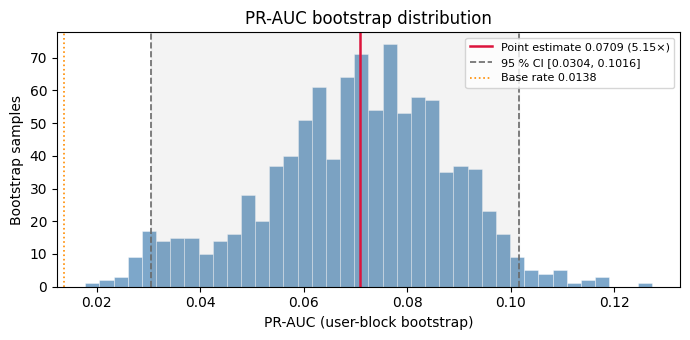

WHALES
users=4 rows=5419 positives=172 base=0.0317
PR-AUC=0.1080 (3.40x)  95% CI=[0.0741, 0.1645] ([2.34x, 5.18x])



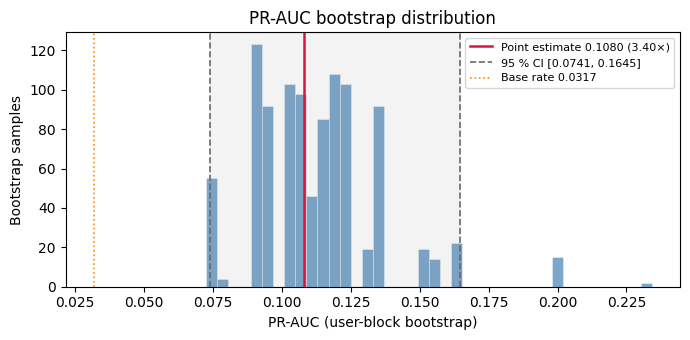

NON-WHALES
users=26 rows=18055 positives=151 base=0.0084
PR-AUC=0.0249 (2.97x)  95% CI=[0.0158, 0.0375] ([1.89x, 4.48x])



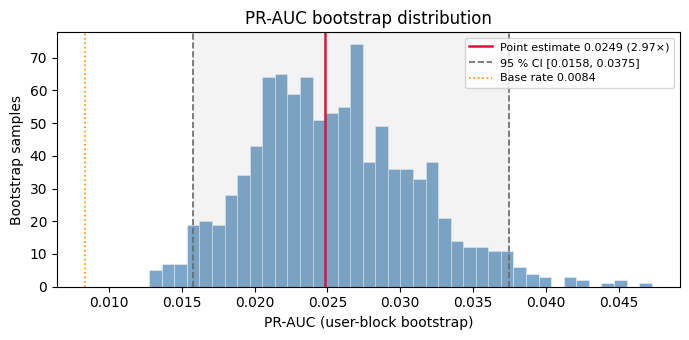

In [30]:
oof_dev_df = pd.read_parquet(DEV_OOF_METRICS)
cal_oof = oof_dev_df["cal_oof"]

boostrap_summary(df_train,cal_oof,"dev_train")

Model Score: dev_test OOF
ALL
users=7 rows=6138 positives=67 base=0.0109
PR-AUC=0.0338 (3.10x)  95% CI=[0.0184, 0.0610] ([1.68x, 5.59x])



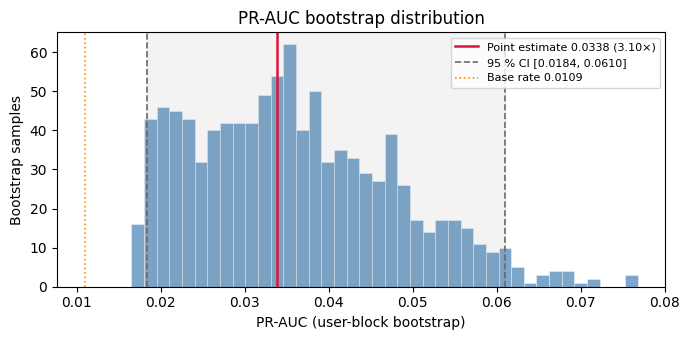

WHALES
users=1 rows=839 positives=24 base=0.0286
PR-AUC=0.0913 (3.19x)  95% CI=[0.0913, 0.0913] ([3.19x, 3.19x])



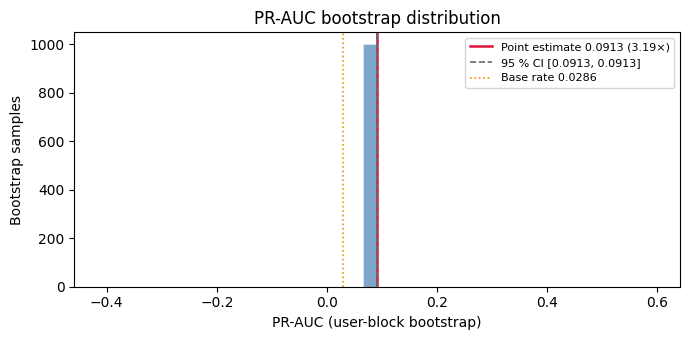

NON-WHALES
users=6 rows=5299 positives=43 base=0.0081
PR-AUC=0.0216 (2.66x)  95% CI=[0.0176, 0.0371] ([2.16x, 4.57x])



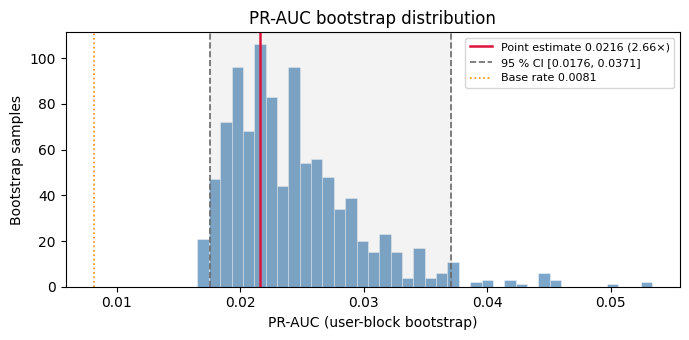

In [31]:
p_cal = model.predict_proba(df_test)

boostrap_summary(df_test,p_cal,"dev_test")

In [32]:
clf = adversarial_validation(df_train[CHOSEN_FEATURES], df_test[CHOSEN_FEATURES])

adversarial AUC = 0.807   (0.5 = identical, ~0.65+ = medium, 0.8+ = strong)


## Calibration

Calibration is performed on pooled out-of-fold (OOF) predictions rather than on in-fold model outputs. Each OOF prediction is generated by a model that was not trained on the corresponding observation, making the pooled OOF set a representative sample of the score distribution expected during deployment. Calibrating on OOF predictions therefore avoids the optimistic bias that can arise when calibration is fitted on scores generated from the same data used for model training.

Probability calibration is performed using Platt scaling, which fits a two-parameter logistic transformation

Platt scaling is selected in preference to isotonic regression because of the limited number of positive examples available for calibration. At a booking rate of approximately 1.3%, the OOF prediction set contains relatively few positive observations. Under these conditions, isotonic regression's non-parametric stepwise fit can become sensitive to sampling variation in the positive class. The parametric form of Platt scaling provides a stronger structural constraint and is generally more stable when calibration data is sparse.

The empirical calibration curves support this choice. Calibration-by-volume plots show both whale and non-whale segments lying slightly below the diagonal, indicating a smooth and largely monotonic pattern of over-prediction. No substantial discontinuities, reversals, or local irregularities are observed. The observed calibration error therefore appears consistent with a simple monotonic distortion, for which a logistic recalibration is sufficient.


In [33]:
p_oof = oof_dev_df["p_oof"]

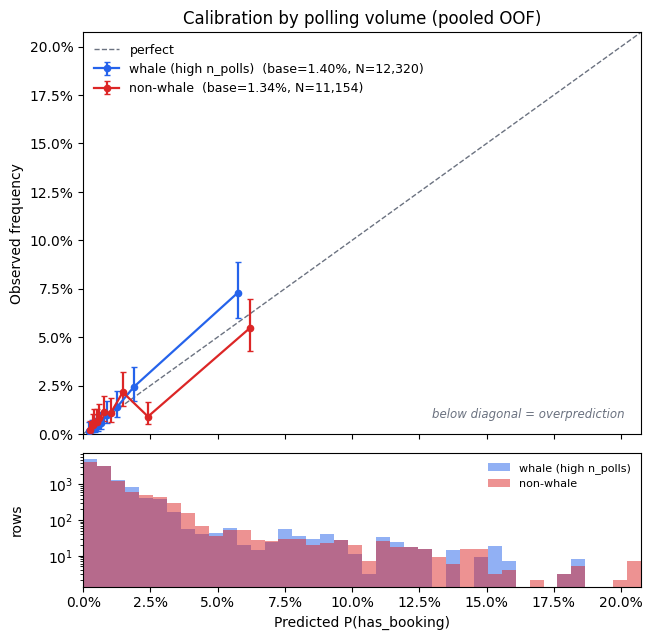

In [34]:
fig = plot_calibration_by_volume(df_train,p_oof);

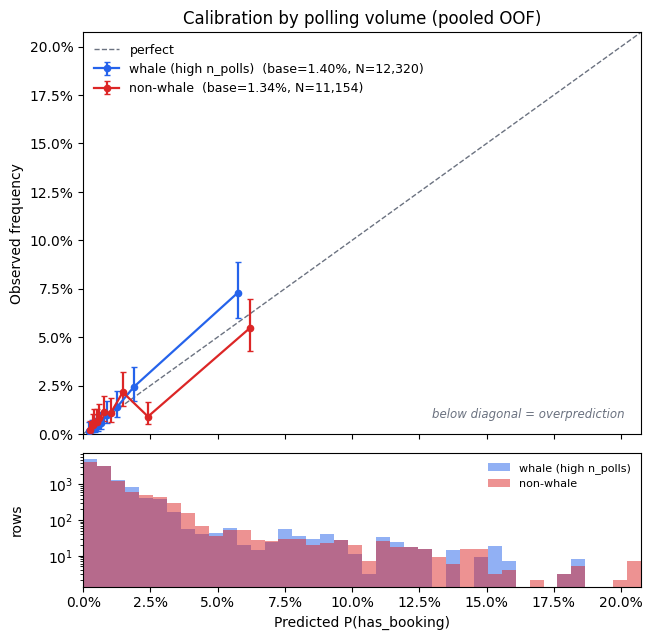

In [35]:
cal_oof = oof_dev_df["cal_oof"]
fig = plot_calibration_by_volume(df_train,p_oof);

## Operational impact: gains-curve analysis

The operational objective is to reduce polling volume while preserving bookings. The most relevant evaluation is therefore the gains curve: if only the top (X%) of polls ranked by predicted probability are retained, what fraction of bookings is preserved?

Operational performance is evaluated relative to the additive timing baseline introduced earlier. The relevant comparison is not whether XGBoost achieves a higher aggregate metric, but whether the additional model complexity produces a meaningful improvement in the polling-versus-booking trade-off.

On the out-of-fold (OOF) dataset, which contains all 30 customers, the resulting operating points are:

|                                                | XGBoost (final) | Additive baseline |
| ---------------------------------------------- | --------------- | ----------------- |
| Polls required to retain 90% of bookings       | ~60% [48–77%]   | ~62% [59–71%]     |
| Polls required to retain 80% of bookings       | ~43%            | ~48%              |
| Polls required to retain 95% of bookings       | ~78%            | ~77%              |
| Bookings contained within the top 10% of polls | ~46%            | ~27%              |

At the 90% booking-retention operating point, the final model and the additive baseline produce very similar results. Approximately 90% of bookings are retained using 60% of polls for XGBoost and 62% of polls for the additive baseline, with bootstrap intervals that overlap substantially.

The largest differences appear at the most selective end of the ranking. Within the top 10% of polls, the final model captures approximately 46% of all bookings compared with 27% for the additive baseline. This concentration effect is also reflected in the PR-AUC results (5.4× base-rate lift versus approximately 2.2× for the additive baseline), indicating that the boosted model is more effective at ranking the highest-probability booking opportunities at the very top of the score distribution.

Two conclusions follow.

First, the primary operational result is largely driven by the timing signal. Retaining approximately 90% of bookings while reducing polling volume by roughly 40% is achievable even with the time-only baseline. This suggests that a substantial portion of the deployable value is already present in the temporal features.

Second, the additional value of the boosted model emerges primarily at lower polling budgets. As the allowed polling volume decreases, the stronger ranking performance concentrates a larger share of bookings into the retained set and provides a more favourable recall-versus-budget trade-off.

The held-out test set produces a similar qualitative result. Retaining approximately 50% of polls preserves roughly 92% of bookings, with 80% booking retention achieved at approximately 44% of polls and 95% retention at approximately 54% of polls. However, the test sample is small and heavily influenced by a single whale customer, making these estimates less stable than their OOF counterparts. Consequently, the OOF gains curve is treated as the primary estimate, while the test curve provides an independent validation check.

All gains-curve results represent an offline counterfactual. They assume that the historical booking process would have remained unchanged under a reduced polling schedule. The true operational effect can only be established through a live deployment experiment.

Taken together, the results support an expected reduction in polling volume of approximately 30–50% while retaining around 90% of bookings, with the conservative estimate derived from the OOF evaluation.


XGB
60% of bookings  ->  20.6% of polling
70% of bookings  ->  27.6% of polling
80% of bookings  ->  42.0% of polling
95% of bookings  ->  75.8% of polling

10% of polling  ->  45.2% of bookings
20% of polling  ->  58.8% of bookings
30% of polling  ->  71.7% of bookings
40% of polling  ->  78.3% of bookings

add
60% of bookings  ->  24.4% of polling
70% of bookings  ->  35.3% of polling
80% of bookings  ->  47.9% of polling
95% of bookings  ->  76.6% of polling

10% of polling  ->  27.3% of bookings
20% of polling  ->  52.6% of bookings
30% of polling  ->  66.3% of bookings
40% of polling  ->  74.3% of bookings


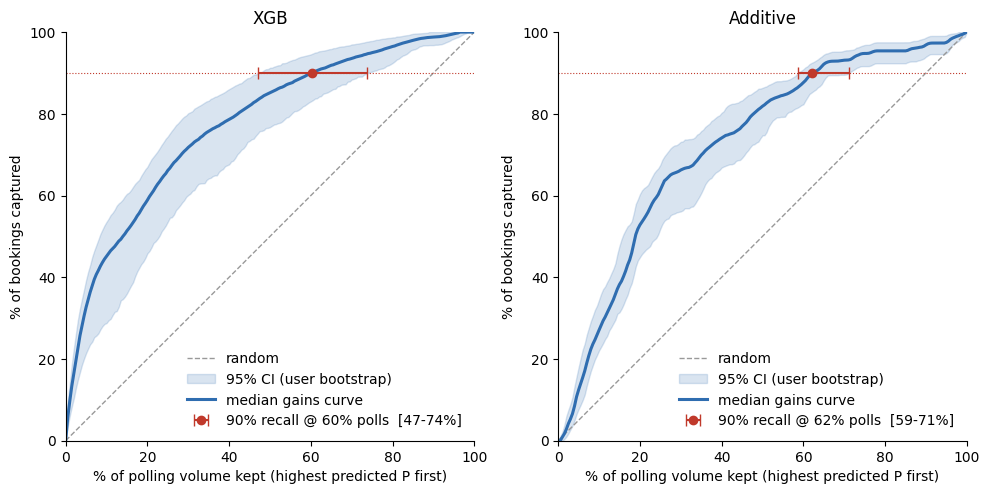

In [36]:
oof_add = np.load(OOF_ADD)
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

res_xgb = gains_bootstrap(df_train, cal_oof.to_numpy())
res_add = gains_bootstrap(df_train, oof_add)

print("XGB")
for target in [0.60, 0.70, 0.80, 0.95]:
    poll_needed = np.interp(target, res_xgb["y"], res_xgb["x"])  
    print(f"{target:.0%} of bookings  ->  {poll_needed:.1%} of polling")

print()
for target in [0.1, 0.2, 0.3, 0.4]:
    recall_at_budget = np.interp(target, res_xgb["x"], res_xgb["y"]) 
    print(f"{target:.0%} of polling  ->  {recall_at_budget:.1%} of bookings")
    

print()
print("add")
for target in [0.60, 0.70, 0.80, 0.95]:
    poll_needed = np.interp(target, res_add["y"], res_add["x"])  
    print(f"{target:.0%} of bookings  ->  {poll_needed:.1%} of polling")

print()
for target in [0.1, 0.2, 0.3, 0.4]:
    recall_at_budget = np.interp(target, res_add["x"], res_add["y"])  
    print(f"{target:.0%} of polling  ->  {recall_at_budget:.1%} of bookings")

bootstrapped_gain_curve(res_xgb,axes[0])
bootstrapped_gain_curve(res_add,axes[1])
axes[0].set_title("XGB")
axes[1].set_title("Additive")

plt.tight_layout()
fig.savefig(REPORTS_FIGURE/"gain_curve_xgb_add.png")


XGB
60% of bookings  ->  20.4% of polling
70% of bookings  ->  28.7% of polling
80% of bookings  ->  37.5% of polling
95% of bookings  ->  53.2% of polling

10% of polling  ->  40.3% of bookings
20% of polling  ->  59.7% of bookings
30% of polling  ->  74.6% of bookings
40% of polling  ->  85.3% of bookings


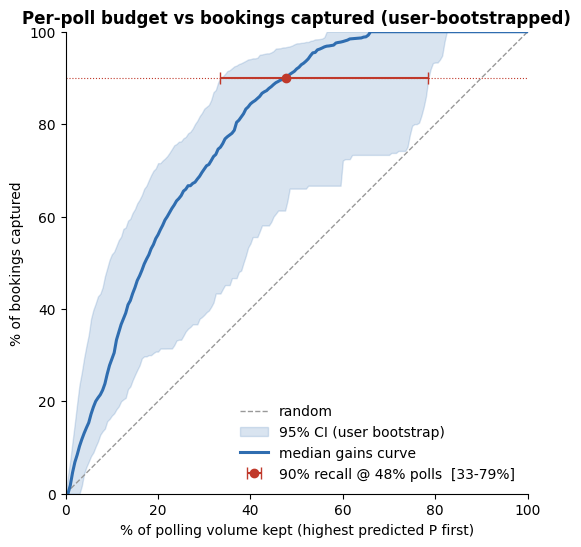

In [37]:
fig, ax = plt.subplots(figsize=(6,6))
test = gains_bootstrap(df_test, p_cal)
print("XGB")
for target in [0.60, 0.70, 0.80, 0.95]:
    poll_needed = np.interp(target, test["y"], test["x"])  
    print(f"{target:.0%} of bookings  ->  {poll_needed:.1%} of polling")

print()
for target in [0.1, 0.2, 0.3, 0.4]:
    recall_at_budget = np.interp(target, test["x"], test["y"]) 
    print(f"{target:.0%} of polling  ->  {recall_at_budget:.1%} of bookings")

bootstrapped_gain_curve(test,ax)
fig.savefig(REPORTS_FIGURE/"test_gain_curve.png")
    

### Per-customer guardrail

The gains curve is an aggregate metric and is therefore heavily influenced by the highest-volume customers. Strong aggregate performance does not guarantee that polling reductions are distributed evenly across individuals. To assess this, recall is evaluated separately for each customer at a fixed polling budget.

The analysis uses a 60% polling budget, corresponding to removal of the lowest-probability 40% of polls. Customer-level recall is then calculated independently for each customer and summarized separately for whale and non-whale segments.

On the OOF dataset, which serves as the primary basis for operational decisions, whale customers retain a median of 93% of bookings (minimum 57%, (n=4)), while non-whale customers retain a median of 100% (minimum 0%, (n=26)).

On the held-out test set, whale customers retain a median of 86% of bookings (minimum 73%, (n=2)), while non-whale customers retain a median of 100% (minimum 57%, (n=5)).

The median results indicate that most customers experience little or no reduction in booking retention under a 40% reduction in polling volume. Non-whale customers typically retain all bookings, while whale customers retain approximately 85–93%.

The worst observed outcomes occur among the lowest-volume customers. For customers with only one or two bookings, a single booking falling below the decision threshold can reduce recall substantially or even to zero. In these cases, customer-level recall becomes a coarse and highly variable statistic because of the small denominator rather than because of a systematic ranking failure.

Despite the limited size of the test panel, the OOF and test results exhibit similar behaviour. Median retention levels are comparable across datasets, and the lowest-performing cases arise from the same low-volume customer population. Consequently, the OOF analysis is used as the primary basis for budget selection, while the held-out test set serves as an independent validation of the observed pattern.


 booking whales: median recall 92%, worst 65%  (n=4)
       the rest: median recall 100%, worst 0%  (n=26)


<Axes: xlabel='whale', ylabel='recall'>

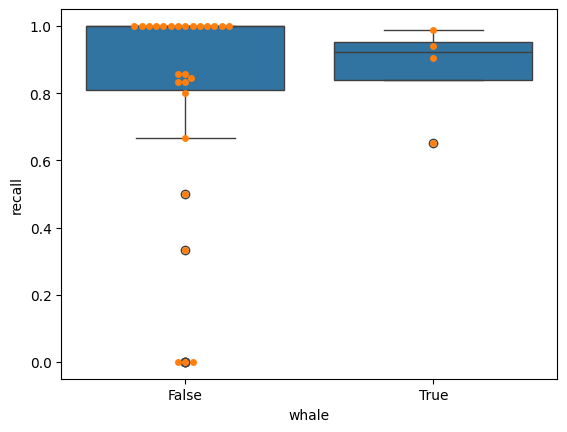

In [38]:
t = per_customer_at_budget(df_train, cal_oof, budget=0.6)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  
sns.swarmplot(data=t,x="whale",y="recall") 

 booking whales: median recall 98%, worst 95%  (n=2)
       the rest: median recall 100%, worst 100%  (n=5)


<Axes: xlabel='whale', ylabel='recall'>

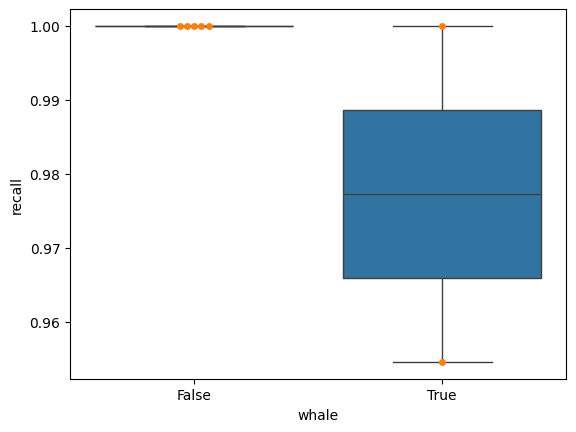

In [39]:
t = per_customer_at_budget(df_test, p_cal, budget=0.6)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  
sns.swarmplot(data=t,x="whale",y="recall")  

## Interpretation: feature importance and SHAP

The interpretation analysis uses TreeSHAP attributions computed on the training data. The beeswarm plot provides a global view of feature importance, while the dependence plots examine the shape of the most influential effects.

By mean absolute SHAP value, the features are ordered as:

`polling_hour` > `pref_unique_timeslot` > `polling_dow` > `class_type` > `is_one_team`

This ranking is broadly consistent with the booking process represented in the data.

* **`polling_hour`** is the most influential feature. Its dependence plot shows strongly negative SHAP values overnight and during the evening, increasing through the morning and remaining positive across the middle of the day. Since bookings become possible only when another learner cancels, the timing of cancellations is expected to be a primary driver of booking probability. The observed SHAP pattern is consistent with cancellations occurring more frequently during daytime hours.

* **`pref_unique_timeslot`** is the second most important feature. Its dependence plot exhibits a threshold-like pattern: customers requesting six or seven distinct timeslots receive a positive contribution, while customers requesting five or fewer receive a negative contribution. A broader set of requested timeslots increases the number of opportunities to match a newly available slot, making wider preference windows easier to satisfy.

* **`polling_dow`** captures a weekday effect, with lower booking probability observed on weekends.

* **`class_type`** and **`is_one_team`** separate one-team and common-pool customers, reflecting the difference in booking difficulty discussed earlier in the bias analysis.

At first glance, the SHAP ranking and the feature-ablation results appear to disagree. The beeswarm plot identifies `polling_hour` as the most important feature, whereas leave-one-out ablation on the final feature set produces the largest performance reduction when `pref_unique_timeslot` is removed.

The apparent discrepancy arises because the two methods quantify different notions of importance. Mean absolute SHAP measures the average contribution of a feature to the model's predicted log-odds across all observations. Since `polling_hour` affects every poll, it accumulates the largest average attribution. In contrast, leave-one-out ablation measures the reduction in ranking performance when a feature is removed. Under this definition, `pref_unique_timeslot` contributes more strongly to the separation between bookings and non-bookings, resulting in the larger PR-AUC reduction.

The two analyses therefore provide complementary perspectives rather than conflicting conclusions. `polling_hour` exerts the largest average influence on predictions, while `pref_unique_timeslot` contributes most strongly to the model's ability to rank positive outcomes ahead of negative ones.

The dependence plot for `polling_hour` also shows little separation by day of week. The overall hourly pattern remains largely unchanged across weekdays, while day-of-week effects primarily shift the level of the prediction. This is consistent with the earlier baseline analysis, where the joint `dow × hour` lookup table failed to outperform the additive formulation. Both analyses therefore suggest that weekday and hour effects are predominantly additive rather than interaction-driven.


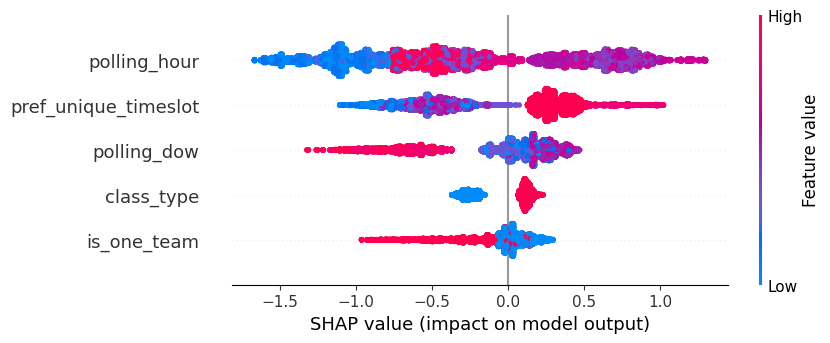

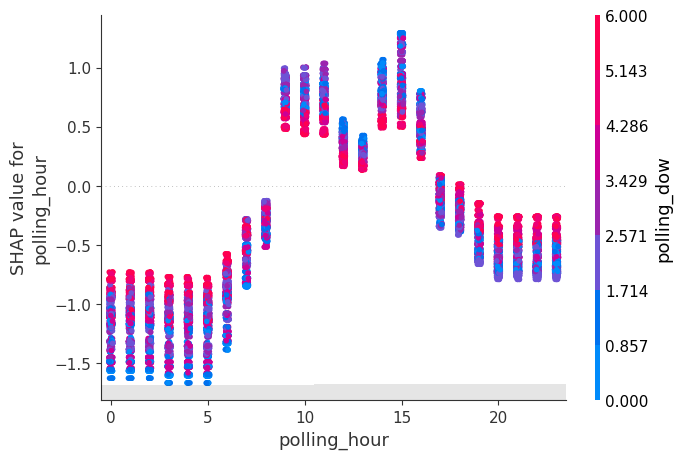

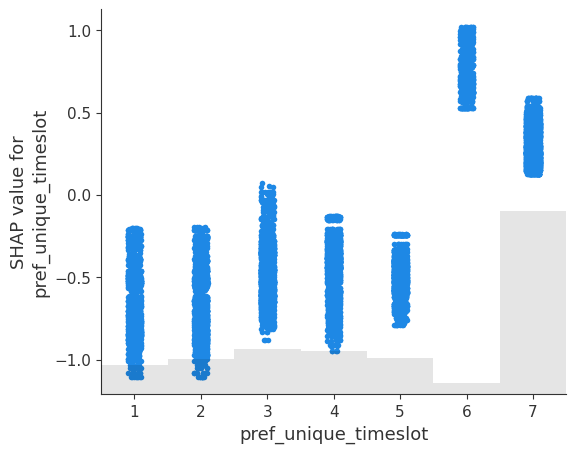

In [40]:
explainer = shap.TreeExplainer(model.booster)
sv = explainer(df_train[CHOSEN_FEATURES])

# Global importance + direction
shap.plots.beeswarm(sv, show=False)
plt.show()

# polling_hour effect, colored by day-of-week — your intraday-cancellation story
shap.plots.scatter(sv[:, "polling_hour"], color=sv[:, "polling_dow"], show=False)
plt.show()

# the preference feature that carried the PR-AUC lift
shap.plots.scatter(sv[:, "pref_unique_timeslot"], show=False)
plt.show()

### Model scope and constraints

The model achieves an out-of-fold (OOF) PR-AUC of 0.075, approximately 5.4× the base rate. At the chosen operating point, this corresponds to roughly a 30–50% reduction in polling while retaining about 90% of bookings. Several limitations should be considered when interpreting these results:

* **Sample-specific metrics.** Evaluation is performed on a collected sample containing only cycles with at least one booking and customers who have provided preferences. As a result, the reported booking rates describe this specific population rather than the full customer base. The metrics should therefore be interpreted as measures of relative ranking performance within the sample, not as population-level booking forecasts.

* **Customer-level uncertainty.** Most uncertainty comes from the limited number of customers rather than the number of observations. The held-out test set contains only seven customers and exhibits a modest distribution shift relative to training data (adversarial AUC 0.70). To reflect this, confidence intervals are estimated using customer-level bootstrapping, while OOF performance is treated as the primary estimate of generalization.

* **Offline counterfactual evaluation.** The gains curve assumes that historical booking and cancellation behavior would remain unchanged if polling volume were reduced. Whether these gains translate into real operational savings can only be confirmed through deployment.

* **Preference-conditioned and coarse time resolution.** The model only evaluates polls within a customer's declared preference windows and operates at hourly granularity. It cannot predict bookings outside those windows or within-hour timing. In practice, this mirrors the behavior of the existing system and is therefore a scope limitation rather than a modeling issue.

* **Seasonality.** The dataset spans roughly nine months, which is insufficient to estimate annual seasonal effects reliably.

### Operational use

The model supports a single operational decision: ranking upcoming polls for each customer by predicted booking probability and executing only the highest-ranked subset. At inference time, only model scores are required. Labels are used offline to estimate the gains curve and select an operating point.

Rather than using a fixed probability threshold, the cutoff is defined as a score quantile—for example, retaining the top 50% of polls. Recomputing this threshold periodically allows the system to adapt to shifts in the score distribution. Based on the gains curve, retaining roughly half of all polls preserves about 90% of bookings, although the retention rate can be adjusted depending on the desired trade-off between polling volume and booking coverage.

Because the OOF predictions are calibrated using Platt scaling, the polling-versus-booking trade-off can also be estimated directly from predicted probabilities. The expected share of bookings retained at a given cutoff is simply the sum of predicted probabilities above the cutoff divided by the sum across all polls. When calibration remains accurate, this estimate closely matches the label-based gains curve and provides a way to monitor expected recall without waiting for booking outcomes to accumulate.

This relies on calibration remaining stable after deployment. The adversarial AUC of 0.70 suggests some distribution shift between customers, which could reduce calibration quality and make these estimates less reliable over time.

Per-customer recall metrics are used as a guardrail to ensure that polling reductions do not disproportionately affect individual customers while aggregate metrics remain strong. Operationally, this is the same score-based quantity calculated at the customer level: the fraction of a customer's predicted booking probability mass retained above the cutoff. Customers whose values fall well below the aggregate target can therefore be identified before deployment as potential starvation cases.

Ultimately, the expected operational impact reported here should be treated as a forecast. Live deployment is required to confirm that the projected reduction in polling volume translates into the anticipated booking retention.


Model Score: prod OOF
ALL
users=37 rows=29612 positives=390 base=0.0132
PR-AUC=0.0468 (3.55x)  95% CI=[0.0236, 0.0742] ([1.79x, 5.64x])



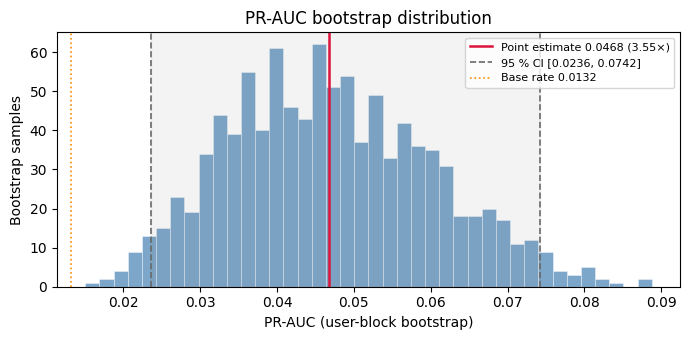

WHALES
users=5 rows=6258 positives=196 base=0.0313
PR-AUC=0.0982 (3.14x)  95% CI=[0.0649, 0.1380] ([2.07x, 4.41x])



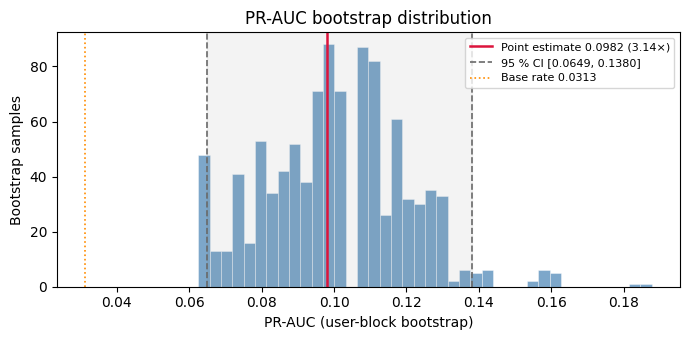

NON-WHALES
users=32 rows=23354 positives=194 base=0.0083
PR-AUC=0.0180 (2.17x)  95% CI=[0.0134, 0.0262] ([1.62x, 3.15x])



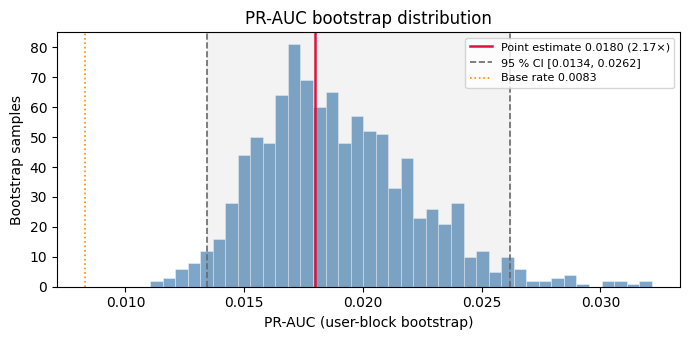

In [41]:
prod_oof_df = pd.read_parquet(PROD_OOF_METRICS)
prod_oof_cal = prod_oof_df["cal_oof"]

boostrap_summary(df,prod_oof_cal,"prod")

 booking whales: median recall 96%, worst 90%  (n=5)
       the rest: median recall 93%, worst 0%  (n=32)


<Axes: xlabel='whale', ylabel='recall'>

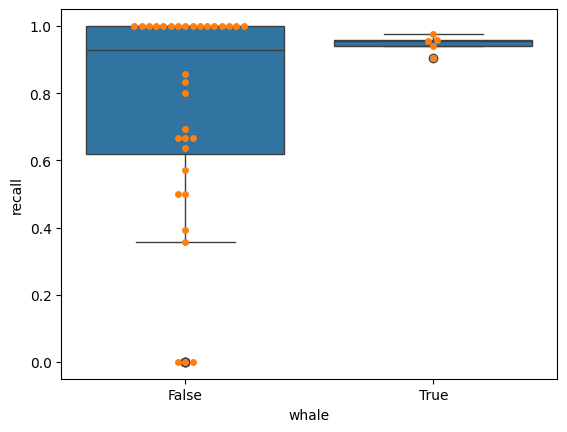

In [42]:
t = per_customer_at_budget(df, prod_oof_cal.to_numpy(), budget=0.5)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  
sns.swarmplot(data=t,x="whale",y="recall")  

PROD
60% of bookings  ->  24.1% of polling
70% of bookings  ->  31.6% of polling
80% of bookings  ->  42.1% of polling
95% of bookings  ->  75.1% of polling

10% of polling  ->  42.3% of bookings
20% of polling  ->  55.4% of bookings
30% of polling  ->  68.5% of bookings
40% of polling  ->  78.2% of bookings


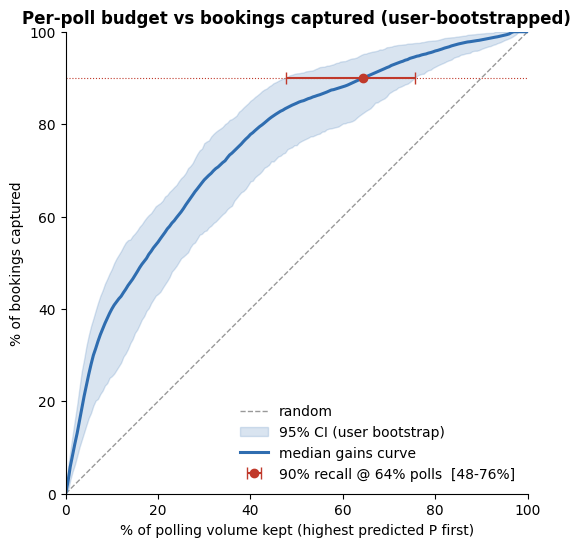

In [43]:
fig, ax = plt.subplots(figsize=(6,6))
prod = gains_bootstrap(df, prod_oof_cal.to_numpy())
print("PROD")
for target in [0.60, 0.70, 0.80, 0.95]:
    poll_needed = np.interp(target, prod["y"], prod["x"])  
    print(f"{target:.0%} of bookings  ->  {poll_needed:.1%} of polling")

print()
for target in [0.1, 0.2, 0.3, 0.4]:
    recall_at_budget = np.interp(target, prod["x"], prod["y"]) 
    print(f"{target:.0%} of polling  ->  {recall_at_budget:.1%} of bookings")

bootstrapped_gain_curve(prod,ax)
fig.savefig(REPORTS_FIGURE/"prod_gain_curve.png")

2026-06-10 00:06:34.738 | DEBUG    | cdc_ml.modeling.predict:predict:41 - Loaded model from C:\Users\zhiju\Desktop\cdc_ml\models\booking_model_v1.joblib
2026-06-10 00:06:34.740 | INFO     | cdc_ml.datasets.cycle.cycle:clean_df:56 - Pre cleaning:9 rows x 9 columns


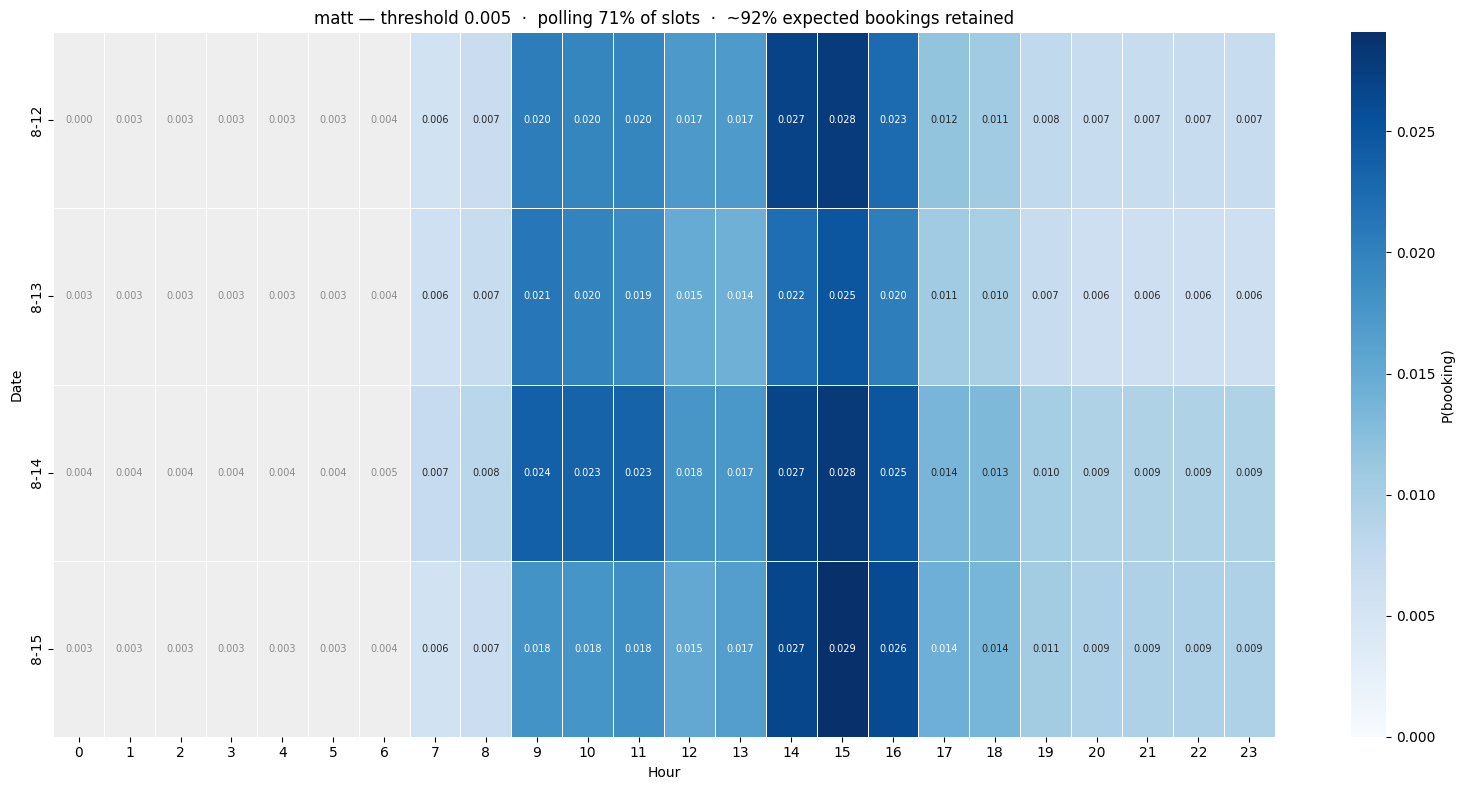

In [44]:
production_visualization("matt",8,15,retention=0.7)